# Satisfacción de Clientes de una Aerolínea

## Objetivo

Analizar los factores que influyen en la satisfacción de los clientes de una aerolínea mediante técnicas de análisis de datos y Machine Learning. El objetivo es identificar qué variables tienen mayor impacto en la experiencia del pasajero para generar información útil que contribuya a la toma de decisiones y a la mejora de los servicios ofrecidos.

----------------------------------------------------------------------

#### 1. Importación de datos y librerías

In [ ]:
### Realizo el import de las librerías que se utilizarán en todo el trabajo
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn import preprocessing
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, roc_auc_score, roc_curve
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [ ]:
### Para llamar al set de datos podemos hacerlo de dos formas: por Drive o de forma local
### IMPORTANTE: Comentar la opción que no se utilice, para que no tire errores

# Google Drive: hay que permitir el acceso y tener el archivo .csv en Drive
# Verify the path and filename. If you are unsure, you can list the files in your Drive using !ls /content/drive/MyDrive/
# dataset = pd.read_csv('/content/drive/MyDrive/Invistico_Airline.csv', sep=',')

### Local: hay que tener cargado el archivo .csv en el google colab, o descargado en el disco si se está ejecutando este archivo desde otro editor, como Visual Studio Code
dataset = pd.read_csv('Invistico_Airline.csv', sep=',')

#### 2. Exploración inicial de datos

##### Visualización inicial del dataset

In [ ]:
### Impresión del set de datos para visualizarlo
dataset.head()

,satisfaction,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Seat comfort,Departure/Arrival time convenient,Food and drink,...,Online support,Ease of Online booking,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Online boarding,Departure Delay in Minutes,Arrival Delay in Minutes
0,satisfied,Female,Loyal Customer,65,Personal Travel,Eco,265,0,0,0,...,2,3,3,0,3,5,3,2,0,0.0
1,satisfied,Male,Loyal Customer,47,Personal Travel,Business,2464,0,0,0,...,2,3,4,4,4,2,3,2,310,305.0
2,satisfied,Female,Loyal Customer,15,Personal Travel,Eco,2138,0,0,0,...,2,2,3,3,4,4,4,2,0,0.0
3,satisfied,Female,Loyal Customer,60,Personal Travel,Eco,623,0,0,0,...,3,1,1,0,1,4,1,3,0,0.0
4,satisfied,Female,Loyal Customer,70,Personal Travel,Eco,354,0,0,0,...,4,2,2,0,2,4,2,5,0,0.0


In [ ]:
### Cambio los nombres de las columnas a español para una comprensión más sencilla
dataset = dataset.rename(columns={
    'satisfaction':'Satisfaccion',
    'Gender':'Genero',
    'Customer Type':'Tipo de cliente',
    'Age':'Edad',
    'Type of Travel':'Tipo de viaje',
    'Class':'Clase',
    'Flight Distance':'Distancia de viaje',
    'Seat comfort':'Comodidad del asiento',
    'Departure/Arrival time convenient':'Horario de salida/llegada conveniente',
    'Food and drink':'Comida y bebida',
    'Gate location':'Ubicacion de puerta',
    'Inflight wifi service':'Servicio de wifi a bordo',
    'Inflight entertainment':'Entretenimiento a bordo',
    'Online support':'Soporte online',
    'Ease of Online booking':'Facilidad de reserva en linea',
    'On-board service':'Servicio a bordo',
    'Leg room service':'Servicio de espacio para piernas',
    'Baggage handling':'Manejo de equipaje',
    'Checkin service':'Servicio de checkin',
    'Cleanliness':'Limpieza',
    'Online boarding':'Embarque en linea',
    'Departure Delay in Minutes':'Retraso de salida en minutos',
    'Arrival Delay in Minutes':'Retraso de llegada en minutos'
})

#### 3. Clasificación de variables del set de datos

**Categóricas**:
- Satisfaccion
- Genero

**Ordinales**:
- Tipo de cliente
- Tipo de viaje
- Clase

**Discretas**:
- Edad
- Comodidad de asiento
- Horario de salida/llegada conveniente
- Comida y bebida
- Ubicación de puerta
- Soporte online
- Facilidad de reserva en linea
- Servicio de wifi a bordo
- Entretenimiento a bordo
- Servicio a bordo
- Servicio de espacio para piernas
- Manejo de equipaje
- Servicio de checkin
- Limpieza
- Embarque en linea

**Continuas**:
- Distancia de viaje
- Retraso de salida en minutos
- Retraso de llegada en minutos

#### 4. Revisión de datos
Por medio de conteo, reviso la cantidad de datos que tiene cada columna.

In [ ]:
### Contamos la cantidad de elementos por columna
dataset.count()

,0
Satisfaccion,129880
Genero,129880
Tipo de cliente,129880
Edad,129880
Tipo de viaje,129880
Clase,129880
Distancia de viaje,129880
Comodidad del asiento,129880
Horario de salida/llegada conveniente,129880
Comida y bebida,129880


Se observa en la última columna que se tienen menos datos que en las demás (129487 vs 129880), así que procedo a realizar una valoración de los datos de esta columna y revisar los datos que faltan.

#### 5. Manejo de valores faltantes
Dado que la columna *Retraso de llegada en minutos* presenta datos faltantes, analizo el comportamiento de los datos para decidir cómo proceder. Primero averiguo si los valores faltantes son nulos.

In [ ]:
# Verifico cantidad de nulos
dataset.isnull().sum()

,0
Satisfaccion,0
Genero,0
Tipo de cliente,0
Edad,0
Tipo de viaje,0
Clase,0
Distancia de viaje,0
Comodidad del asiento,0
Horario de salida/llegada conveniente,0
Comida y bebida,0


Se observa que la cantidad de nulos en la columna es 393, que coincide exactamente con la diferencia en cantidad de datos de esta columna y las demás (129880-129487=393).

Calculo la media y la mediana para observar la dispersión de los datos.

In [ ]:
median_retraso_llegada = dataset['Retraso de llegada en minutos'].median()
print("La mediana de la columna 'Retraso de llegada en minutos' es: ", median_retraso_llegada)
print("La media de la columna 'Retraso de llegada en minutos' es: ", round(dataset['Retraso de llegada en minutos'].mean(), 2))

La mediana de la columna 'Retraso de llegada en minutos' es:  0.0
La media de la columna 'Retraso de llegada en minutos' es:  15.09


In [ ]:
print("La cantidad de datos de la columna que son cero es: ", (dataset['Retraso de llegada en minutos'] == 0).sum())

La cantidad de datos de la columna que son cero es:  72753


Dado que más del 56% (72753*100/129880=56,02) de los valores son cero, la mediana (0) es más representativa de la ausencia de retrasos para la mayoría de los vuelos. Por lo tanto, completo los valores nulos con la mediana para evitar introducir un sesgo artificial de retraso en estos registros.

In [ ]:
# reemplazo los valores nulos con la mediana
dataset.fillna({'Retraso de llegada en minutos':median_retraso_llegada}, inplace=True)

# verifico el conteo de datos nuevamente
print("\nConteo de datos después de rellenar valores nulos:")
dataset.count()


Conteo de datos después de rellenar valores nulos:


,0
Satisfaccion,129880
Genero,129880
Tipo de cliente,129880
Edad,129880
Tipo de viaje,129880
Clase,129880
Distancia de viaje,129880
Comodidad del asiento,129880
Horario de salida/llegada conveniente,129880
Comida y bebida,129880


#### 6. Análisis descriptivo de los datos
Luego de haber realizado la revisión de los datos, procedo a entender el comportamiento de los datos a través de distintos análisis y por medio del armado de diferentes tipos de gráficos. Esto ayudará a entender cómo se ditribuyen los datos, las relaciones entre ellos y la existencia de casos atípicos en caso de que haya.

##### 6.1. Análisis univariado
Procedo a hacer un análisis sobre las variables de los pasajeros (edad y género) y un análisis sobre las variables del vuelo (distancia, tipo y clase), para entender que variables tienen más importancia a la hora de medir la satisfacción para los distintos tipos de pasajeros.

Después del análisis de estas variables, realizo un estudio de la calificación por satisfacción.
Es importante conocer la cantidad de encuestados y la calificación que le dieron a la aerolínea, ya que puede resultar ser relevante para futuros análisis.

--------------------------------------

**Análisis de los pasajeros**

-------------------------------------

*Por edad*

La mediana es:  40.0
La media es:  39.43


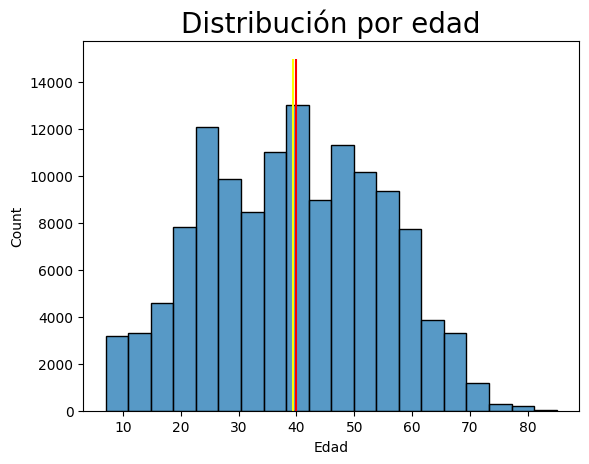

In [ ]:
plt.title('Distribución por edad', fontsize=20)
sns.histplot(dataset.Edad, bins=20)
plt.vlines(dataset.Edad.median(), 0, 15000, color='red')
plt.vlines(dataset.Edad.mean(), 0, 15000, color='yellow');

print("La mediana es: ", dataset.Edad.median())
print("La media es: ", round(dataset.Edad.mean(), 2))

El histograma de distribución por edad muestra la frecuencia de pasajeros en diferentes rangos de edad. Podemos observar una distribución con una mediana de **40 años** y una media de aproximadamente **39.43 años**. Esto sugiere que la mayoría de los pasajeros se encuentran en el rango de adultos, con una concentración notable alrededor de los 25 a 55 años. Visualmente, el histograma presenta una forma de campana, donde la mayor frecuencia de pasajeros se sitúa en las edades centrales, disminuyendo gradualmente hacia los extremos, que van desde los 7 hasta los 85 años. Esto confirma que la aerolínea atiende a un amplio rango de edades, pero con una clara mayoría en el segmento de adultos. Esta distribución de edad podría ser un factor a considerar en la predicción de satisfacción, ya que diferentes grupos etarios podrían tener distintas expectativas o valoraciones sobre el servicio.

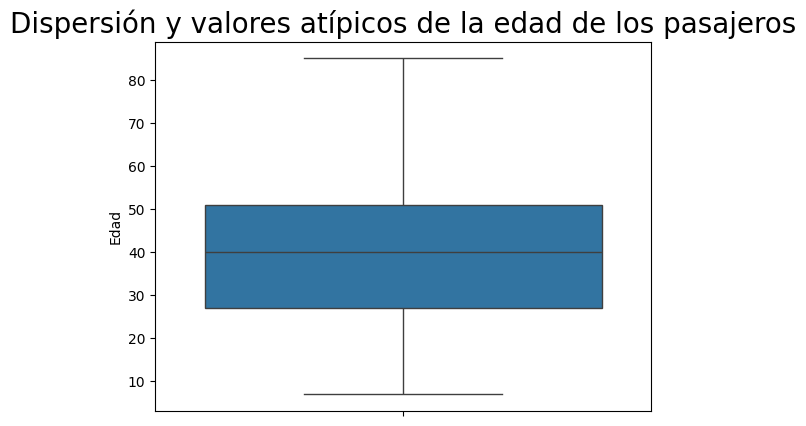

In [ ]:
plt.title('Dispersión y valores atípicos de la edad de los pasajeros', fontsize=20)
ns.boxplot(dataset.Edad);

In [ ]:
# Información adicional sobre la edad de los pasajeros
round(dataset['Edad'].describe(), 2)

,Edad
count,129880.00
mean,39.43
std,15.12
min,7.00
25%,27.00
50%,40.00
75%,51.00
max,85.00


El boxplot de la variable 'Edad' permite identificar la distribución y la presencia de valores atípicos. Como podemos observar:

- La **mediana** es de **40 años**, como se había calculado anteriormente, lo que indica que la mitad de los pasajeros tienen 40 años o menos.
- El **rango intercuartílico (IQR)** abarca desde los **27 años (Q1)** hasta los **51 años (Q3)**. Esto significa que la mayoria de los pasajeros se encuentra en este rango de edad.
- Los **bigotes** del boxplot se extienden desde el mínimo de **7 años** hasta el máximo de **85 años**. La ausencia de puntos individuales fuera de los bigotes confirma que **no hay outliers** (valores atípicos) en la distribución de la edad, lo que sugiere que los datos de edad están bien contenidos dentro de un rango esperado para los viajeros.
- Se observa a su vez que la mediana se acerca más al valor del Q3 que al de Q1, por lo que la edad se encuentra levemente sesgada hacia edades mayores a 40 años.


---



*Por género*

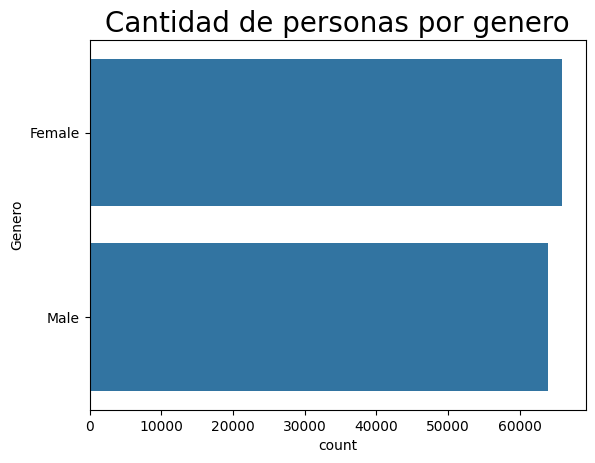

In [ ]:
plt.title('Cantidad de personas por genero', fontsize=20)
sns.countplot(dataset.Genero);

In [ ]:
# Información adicional sobre el género de los pasajeros
dataset['Genero'].describe()

,Genero
count,129880
unique,2
top,Female
freq,65899


Este countplot visualiza la distribución de pasajeros por **género**. Se puede observar que la cantidad de pasajeros masculinos y femeninos es prácticamente simétrica, aunque hay una leve predominancia de **mujeres** ('Female') sobre **hombres** ('Male') en el dataset, con un total de **65899** mujeres y **63981** hombres (~51% de mujeres). Esto indica que la aerolínea atiende a una base de clientes con una representación de género no sesgada. Sin embargo, se explorará más en detalle más adelante si las diferencias de género en la satisfacción podrían ser un predictor importante.

-------------------------------------

**Análisis del viaje**

------------------------------------

*Por distancia*

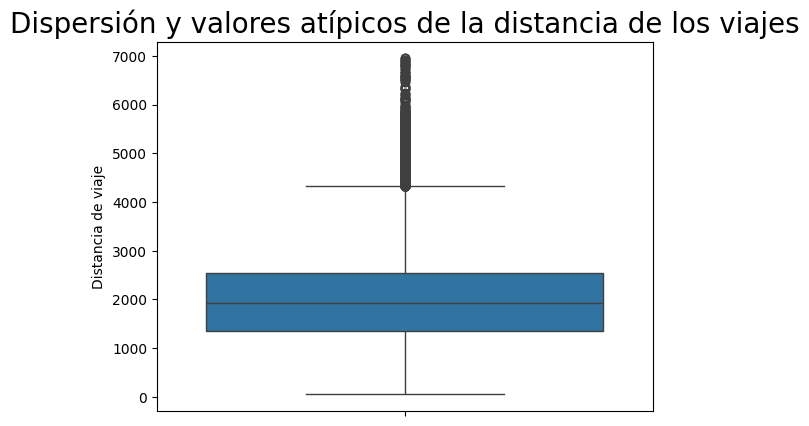

In [ ]:
plt.title('Dispersión y valores atípicos de la distancia de los viajes', fontsize=20)
sns.boxplot(dataset['Distancia de viaje']);

In [ ]:
print("La mediana es: ", dataset['Distancia de viaje'].median())
round(dataset['Distancia de viaje'].describe(), 2)

La mediana es:  1925.0


,Distancia de viaje
count,129880.00
mean,1981.41
std,1027.12
min,50.00
25%,1359.00
50%,1925.00
75%,2544.00
max,6951.00


Analizo también los límites de la caja, el bigote mínimo y el bigote máximo.

In [ ]:
q1 = dataset['Distancia de viaje'].quantile(0.25)
q3 = dataset['Distancia de viaje'].quantile(0.75)

iqr = q3 - q1

limite_inferior_teorico = q1 - 1.5 * iqr
limite_superior_teorico = q3 + 1.5 * iqr

bigote_inferior = dataset[dataset['Distancia de viaje'] >= limite_inferior_teorico]['Distancia de viaje'].min()
bigote_superior = dataset[dataset['Distancia de viaje'] <= limite_superior_teorico]['Distancia de viaje'].max()

print(f"Bigote Inferior: {bigote_inferior}")
print(f"Bigote Superior: {bigote_superior}")

Bigote Inferior: 50
Bigote Superior: 4321


Adicionalmente, reviso cantidad de valores atípicos.

In [ ]:
cantidad_outliers = dataset[(dataset['Distancia de viaje'] < bigote_inferior) | (dataset['Distancia de viaje'] > bigote_superior)].shape[0]

print(f"Total de valores atípicos: {cantidad_outliers}")

Total de valores atípicos: 2581


El boxplot en distancia de viaje nos permite determinar lo siguiente:

- La **mediana** es de **1925 km**, lo que indica que el 50% de los vuelos tienen una distancia menor o igual a este valor, mientras que la **media** es de **1981 km**, lo que resulta en una distribución de los datos **asimétrica positiva** (mediana < media), por lo que esto significa que hay más larga de vuelos de larga distancia que de corta distancia.
- El **rango intercuartil** de la distancia de viaje se encuentra entre **1359 km (Q1)** y **2544 km (Q3)**. Esto significa que la mitad central de los vuelos se encuentra dentro de este rango de distancia.
- La distancia de viaje mínima fue de **50 km** y la máxima fue de **6951 km**, incluyendo los valores atípicos.
- Para esta variable sí se observan valores atípicos, siendo mayores al máximo valor del boxplot (el bigote superior). El bigote superior tiene el valor de **4321 km**, por lo que los valores superiores a este se consideran atípicos. La cantidad de valores atípicos es **2581** respecto al total de **129880**, lo que representa aproximadamente el **1.99%** (2581*100/129880=1.99) de los viajes. Esto nos revela que una gran proporción de los viajes son de larga distancia, lo que no necesariamente es un error en los datos sino una característica de la operación de la aerolínea. Para el modelado, estos valores atípicos se conservarán ya que representan un segmento real de clientes y vuelos que podrían tener patrones de satisfacción diferentes.


---



*Por tipo de viaje*

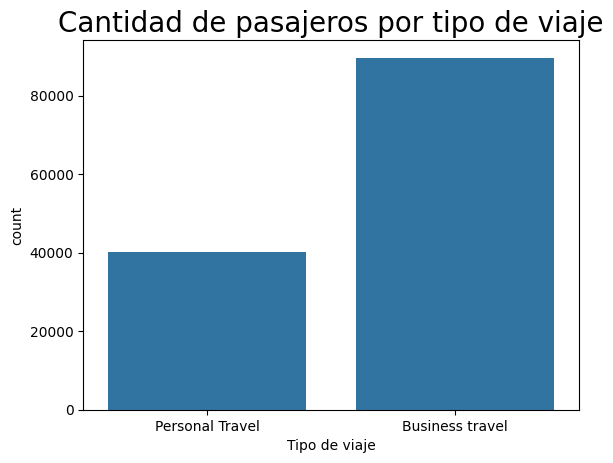

In [ ]:
plt.title('Cantidad de pasajeros por tipo de viaje', fontsize=20)
sns.countplot(data=dataset, x='Tipo de viaje');

In [ ]:
# Información adicional sobre el tipo de viaje
dataset['Tipo de viaje'].describe()

,Tipo de viaje
count,129880
unique,2
top,Business travel
freq,89693


El gráfico countplot visualiza la distribución de pasajeros según el **Tipo de viaje** que realizaron. Se observan dos categorías: Personal vs Business, siendo este último el mayoritario y con un valor de **89693** viajes, que representa un **69%** (89693*100/129880=69.06) de los viajes. Esto indica una segmentación clara y observable en la base de clientes de la aerolínea, donde los viajes de negocios son el principal motor. Es plausible que las expectativas y factores de satisfacción difieran significativamente entre viajeros personales y de negocios, lo que hace de esta una variable clave para el modelo predictivo.


---



*Por clase*

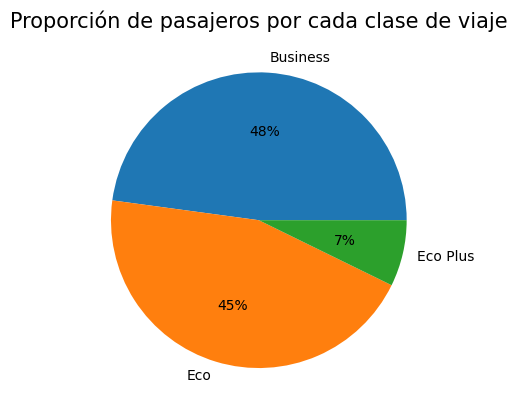

In [ ]:
data = list(dataset.Clase.value_counts().values)
keys = list(dataset.Clase.value_counts().index)
plt.title('Proporción de pasajeros por cada clase de viaje', fontsize=15)
plt.pie(data, labels=keys, autopct='%.0f%%');

Este gráfico de torta o pie chart muestra la proporción de pasajeros por cada **clase de viaje**. Analizando el gráfico, podemos concluir que hay una división significativa entre pasajeros que eligen viajes más **económicos** ('Eco') y aquellos que optan por opciones **más exclusivas o de negocios** ('Business' o 'Eco Plus'), sugiriendo una base de clientes que elige los extremos en cuanto a precios de pasajes. Se observará mediante análisis bivariado si la clase de viaje se perfila como un factor determinante en la satisfacción del cliente.


---



**Análisis de la satisfacción**

------------------------------------

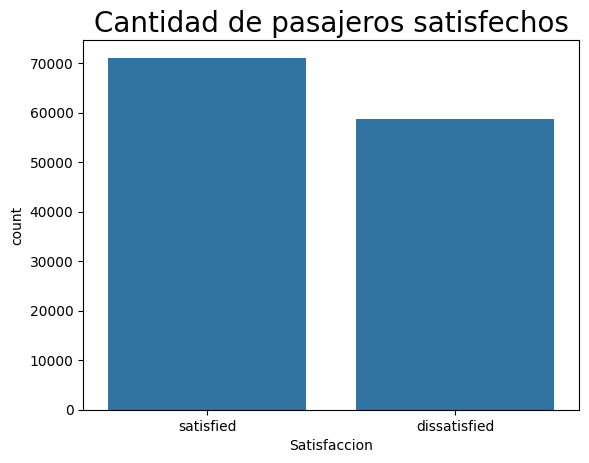

In [ ]:
plt.title('Cantidad de pasajeros satisfechos', fontsize=20)
sns.countplot(data=dataset, x='Satisfaccion');

In [ ]:
# Información adicional sobre la satisfacción de los clientes
dataset['Satisfaccion'].describe()

,Satisfaccion
count,129880
unique,2
top,satisfied
freq,71087


Se observa que la cantidad de clientes satisfechos es ligeramente mayor que la cantidad de clientes insatisfechos, siendo **55%** (71087.100/129880=54,73) y **45%** (58793.100/129880=45,27) respectivamente. Este será nuestro objetivo, determinar cómo influyen las demás en esta variable. Además, como la diferencia en cantidades entre satisfechos e insatisfechos no es muy grande, los modelos que se entrenarán a futuro no se verán sesgados por alguna de las dos posibilidades.


---



##### 6.2. Análisis bivariado

Se observarán a continuación diversos análisis bivariados, buscando relaciones entre las variables de los clientes, de los viajes y la satisfacción de los clientes en esos viajes.

------------------------------------------------------------

**Satisfacción de los clientes vs la clase en la que viajaron**

La clase en la que viajan los clientes puede resultar ser un factor clave para determinar el nivel de satisfacción de clientes, ya que las clases presentan distintos servicios que los clientes contratan.

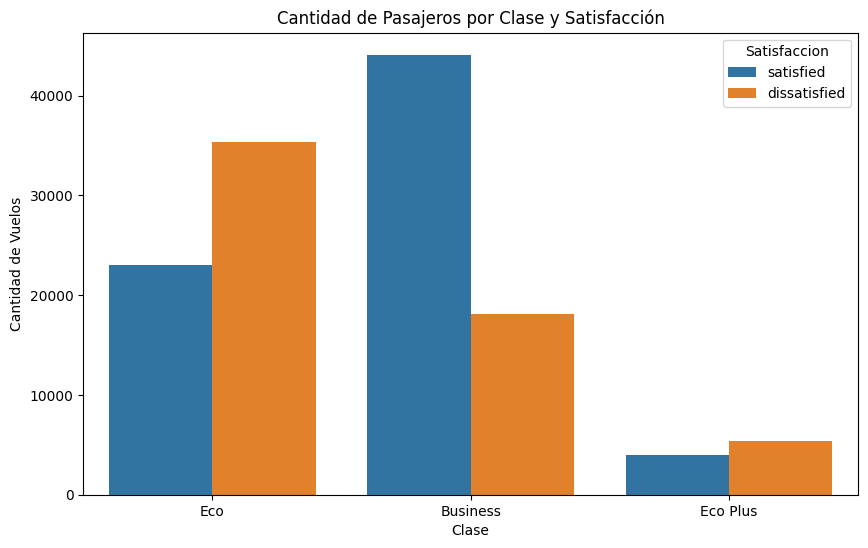

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(x='Clase', hue='Satisfaccion', data=dataset)
plt.title('Cantidad de Pasajeros por Clase y Satisfacción')
plt.xlabel('Clase')
plt.ylabel('Cantidad de Vuelos')
plt.show()

Existe una clara segmentación de la satisfacción según la clase. Mientras que la clase **Business** actúa como un fuerte indicador de **satisfacción positiva**, las clases **Eco y Eco Plus** presentan una **tendencia inversa**, concentrando la mayor proporción de pasajeros insatisfechos. Esta observación sugiere que la 'Clase' será una de las variables predictoras clave para el modelo de satisfacción.

---

**Satisfacción del cliente vs el servicio de wifi a bordo**

Como se mencionó previamente, los servicios a bordo pueden ser un factor fundamental en la satisfacción de los clientes, por lo que se analizarán algunos servicios relevantes que se les brindan durante el vuelo.

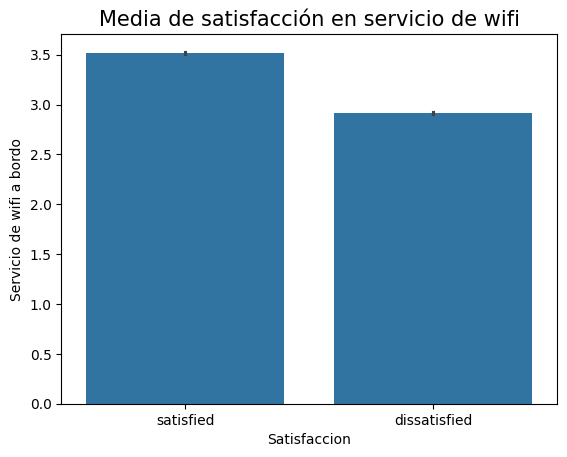

In [ ]:
plt.title('Media de satisfacción en servicio de wifi', fontsize=15)
sns.barplot(x=dataset.Satisfaccion, y=dataset['Servicio de wifi a bordo']);

Este barplot muestra la calificación promedio de satisfacción de los pasajeros con el servicio de Wi-Fi a bordo. Como se puede observar, las calificaciones son generalmente bajas tanto para los pasajeros satisfechos como para los insatisfechos. Esto indica que, en general, el servicio de Wi-Fi es un área donde la aerolínea tiene una oportunidad de mejora. Sin embargo, el hecho de que incluso aquellos que se consideran **'satisfechos'** no le otorguen una puntuación significativamente superior a los **'insatisfechos'** podría sugerir que, aunque valorado, el Wi-Fi no es el factor principal que impulsa la satisfacción general del cliente.

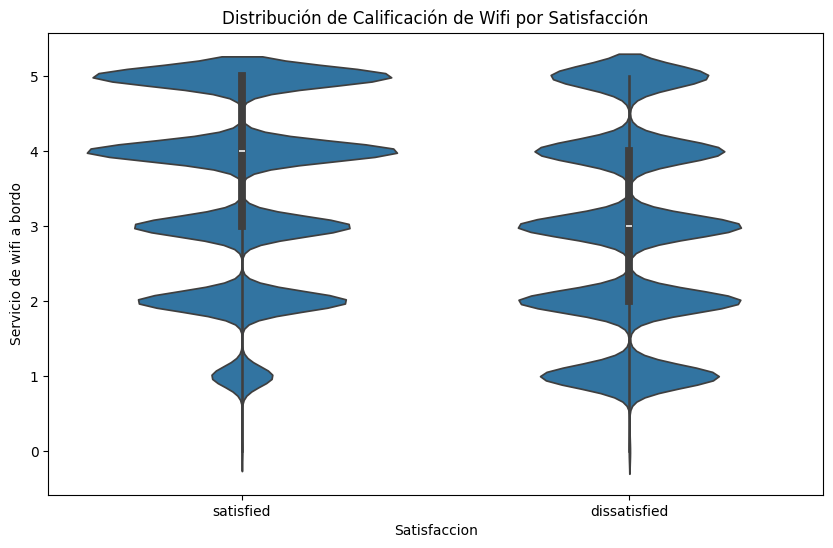

In [ ]:
plt.figure(figsize=(10, 6))
sns.violinplot(x='Satisfaccion', y='Servicio de wifi a bordo', data=dataset)
plt.title('Distribución de Calificación de Wifi por Satisfacción')
plt.show()

In [ ]:
conteo_detallado = dataset[['Servicio de wifi a bordo', 'Satisfaccion']].value_counts().sort_index()
print(conteo_detallado)

Servicio de wifi a bordo  Satisfaccion
0                         dissatisfied       73
                          satisfied          59
1                         dissatisfied    10762
                          satisfied        3949
2                         dissatisfied    13464
                          satisfied       13581
3                         dissatisfied    13535
                          satisfied       14067
4                         dissatisfied    11423
                          satisfied       20137
5                         dissatisfied     9536
                          satisfied       19294
Name: count, dtype: int64


Este gráfico de violín o violinplot, junto con el conteo detallado, permite hipotetizar que el WiFi podría no ser uno de los atributos más influyentes para el cliente a la hora de determinar su satisfacción general. Si así fuera, se debería apreciar una diferencia más marcada en la distribución de valoraciones entre los clientes **insatisfechos** y **satisfechos**, especialmente en las valoraciones extremas del servicio (0 y 5). Aunque sí es cierto que existe una oportunidad de mejora por parte de la aerolínea en este servicio, es posible que no sea un factor prioritario para la predicción de la satisfacción.

---

**Satisfacción de los clientes vs la atención que reciben**

La atención al cliente siempre resulta en un factor determinante de la satisfacción de los clientes, indistintamente del rubro que se analice, por lo que resulta prioritario incluirla en el análisis.

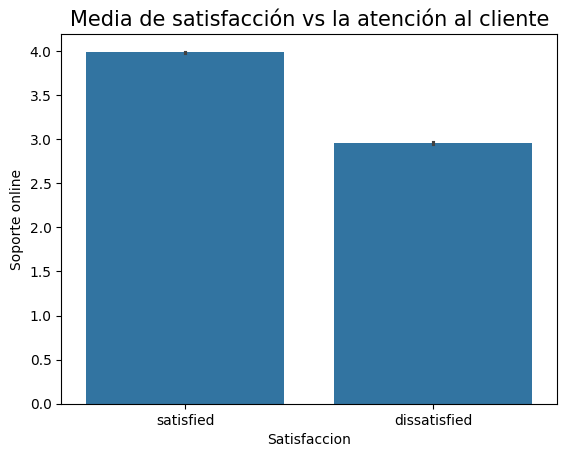

In [ ]:
plt.title('Media de satisfacción vs la atención al cliente', fontsize=15)
sns.barplot(x=dataset.Satisfaccion, y=dataset['Soporte online']);

Este barplot  muestra la calificación promedio de satisfacción de los pasajeros respecto al **soporte online** (atención al cliente). Podemos observar que los pasajeros clasificados como **'satisfechos'** otorgan una puntuación significativamente más alta al **Soporte online** que aquellos clasificados como **'insatisfechos'**, lo que es un resultado esperable. Esto resalta que una buena experiencia con el soporte online es un factor clave para la satisfacción general del cliente, y que hay una clara diferencia en cómo perciben este servicio los dos grupos. Por lo tanto, el nivel de **Soporte online** se presenta como una variable predictora potencialmente muy relevante.

---

**Satisfacción de los clientes vs limpieza**

La limpieza y el orden de los aviones también resulta ser un factor que, por intuición, puede influir significativamente en la satisfacción de los clientes.

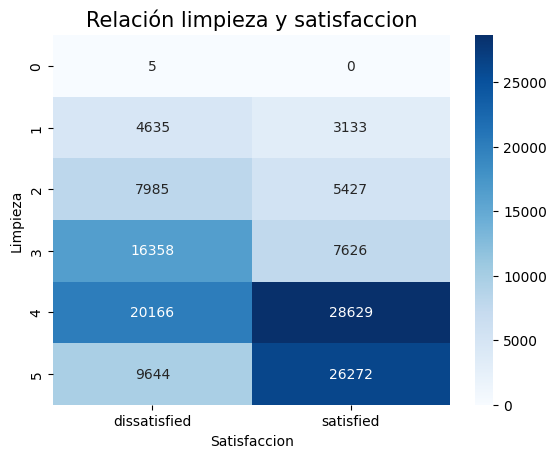

In [ ]:
plt.title('Relación limpieza y satisfaccion', fontsize=15)
sns.heatmap(pd.crosstab(dataset.Limpieza, dataset.Satisfaccion), annot=True, fmt='g',cmap='Blues');

In [ ]:
calificaciones_altas_limpieza = dataset[dataset['Limpieza'] >= 3].shape[0]
total_pasajeros = dataset.shape[0]
porcentaje_calificaciones_altas = (calificaciones_altas_limpieza / total_pasajeros) * 100

print(f"Cantidad de pasajeros que calificaron la limpieza con 3 o más puntos: {calificaciones_altas_limpieza}")
print(f"Porcentaje de pasajeros que calificaron la limpieza con 3 o más puntos: {porcentaje_calificaciones_altas:.2f}%")

Cantidad de pasajeros que calificaron la limpieza con 3 o más puntos: 108695
Porcentaje de pasajeros que calificaron la limpieza con 3 o más puntos: 83.69%


Este heatmap muestra la relación entre la calificación de **Limpieza** y la **Satisfacción** general de los pasajeros. Se observa que los pasajeros en general calificaron con 3 puntos o más al servicio de limpieza, siendo en total **108695** (si sumamos las cantidades de pasajeros que calificaron con 3 o más puntos, tanto satisfechos como insatisfechos), lo que representa un **83.69%** del total de casos analizados. Esto nos lleva a formular la hipótesis de que la limpieza de los aviones, si bien es importante, no parece ser un factor que cause una gran insatisfacción en los clientes, dado que la mayoría la valora positivamente, incluso entre los insatisfechos. Podría tener un peso menor en la predicción de la insatisfacción en comparación con otros factores.

---

**Satisfacción de los clientes vs el género**

Analizamos si el género de los clientes puede ser un factor determinante de la satisfacción. Si es así, se podrían desarrollar más hipótesis que permitan comprender la insatisfacción y aplicar medidas que corrijan esto.

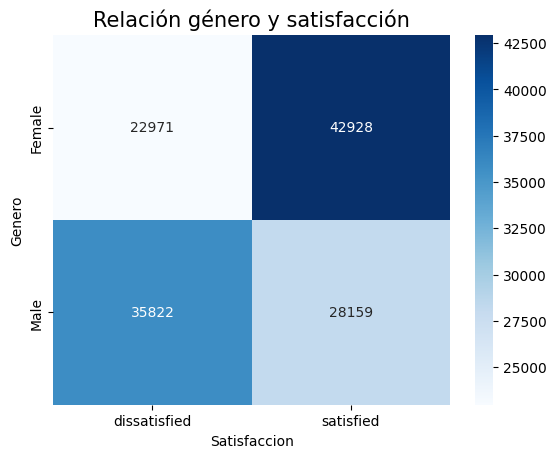

In [ ]:
plt.title('Relación género y satisfacción', fontsize=15)
sns.heatmap(pd.crosstab(dataset.Genero, dataset.Satisfaccion), annot=True, fmt='g',cmap='Blues');

Este heatmap muestra la distribución de la **satisfacción** (satisfecho vs. insatisfecho) en función del **género** de los pasajeros. Cada celda indica la cantidad de pasajeros que caen en cada combinación de género y nivel de satisfacción.

Se puede observar que, del total de la muestra:
- Hay una mayor cantidad de **pasajeras femeninas satisfechas** en comparación con las insatisfechas, siendo **42928** de pasajeras satisfechas, lo que representa un **33%** de los pasajeros en general (42928*100/129880=33.05).
- Por otro lado, se observó una mayor proporción de pasajeros masculinos dentro del grupo de clientes insatisfechos. en comparación, siendo **35822** el total de pasajeros hombres insatisfechos, lo que representa un **28%** respecto al total general (35822*100/129880=27.58).

Esto sugiere una diferencia en los niveles de satisfacción entre géneros, lo cual podría indicar que ciertos aspectos del servicio de la aerolínea afectan de manera diferente la experiencia de hombres y mujeres. Esta variable podría ser un predictor relevante de la satisfacción del cliente.

---

**Correlación entre retraso de salida y llegada**

Analizo si existe correlación entre las variables de *Retraso de salida* y *Retraso de llegada*.

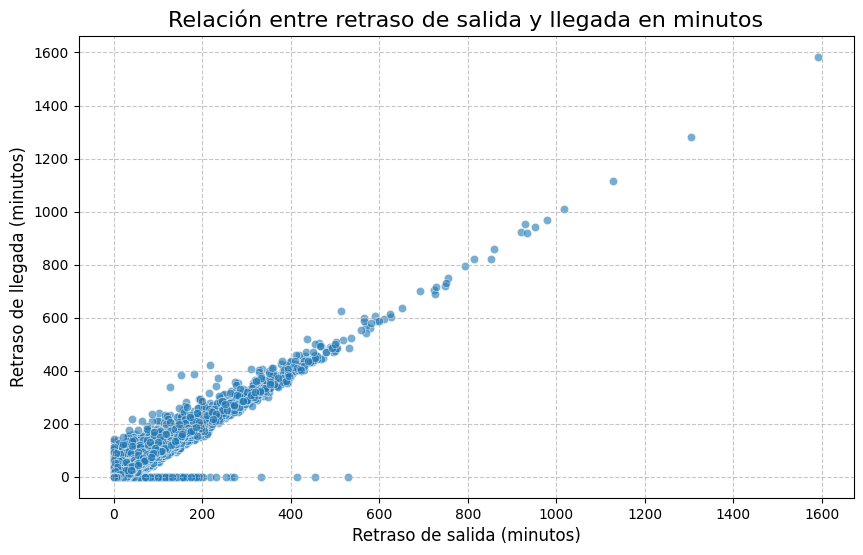

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Retraso de salida en minutos', y='Retraso de llegada en minutos', data=dataset, alpha=0.6)
plt.title('Relación entre retraso de salida y llegada en minutos', fontsize=16)
plt.xlabel('Retraso de salida (minutos)', fontsize=12)
plt.ylabel('Retraso de llegada (minutos)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

Este gráfico de dispersión visualiza la relación entre el **'Retraso de salida en minutos'** y el **'Retraso de llegada en minutos'**. Se observa una alta correlación positiva: a medida que aumenta el retraso en la salida, también tiende a aumentar el retraso en la llegada. La mayoría de los puntos se agrupan en valores bajos de retraso para ambos ejes, indicando que la mayoría de los vuelos salen y llegan a tiempo o con pequeños retrasos. Sin embargo, los puntos dispersos en la parte superior derecha del gráfico muestran casos donde tanto la salida como la llegada experimentan retrasos significativos. Para la predicción de satisfacción, esta fuerte correlación sugiere que podríamos considerar una de estas variables, o una combinación, para representar el impacto del retraso en el viaje.

---

#### 7. Conclusiones preliminares del análisis exploratorio

Del análisis realizado respecto a los datos del dataset se puede determinar varios hechos y sus posibles implicaciones para el modelo predictivo:

-   La **edad promedio de los pasajeros ronda los 40 años**, con un rango intercuartil entre los 27 y los 51 años. No se observan valores atípicos extremos en la distribución de edad, lo que indica un rango coherente de clientes. La edad podría influir en las expectativas del servicio y, por ende, en la satisfacción.
-   La muestra no está sesgada por el **género de los pasajeros**, con una distribución casi equitativa (51% mujeres, 49% hombres). Sin embargo, se ha observado una diferencia en la satisfacción general entre géneros, lo que sugiere que 'Género' podría ser una característica predictora importante.
-   Los viajes realizados tienen una **mediana de 1925 km** de distancia, con una proporción significativa de vuelos de larga distancia (1.99% de valores atípicos). Esta característica es importante, ya que la duración del vuelo podría estar relacionada con la percepción de diferentes servicios (ej. entretenimiento, comodidad).
-   El **principal motivo de los viajes es por negocios (69%)**. El 'Tipo de viaje' (negocios vs. personal) es una variable clave, ya que las prioridades y la tolerancia a inconvenientes pueden diferir sustancialmente entre estos dos segmentos de clientes.
-   La **mayoría de los pasajeros prefiere los asientos más económicos (Eco, 45%) o los más caros (Business, 48%)**, dejando la opción intermedia (Eco Plus) menos utilizada. Es crucial destacar que los pasajeros de **Clase Business se encuentran más satisfechos** con el servicio en general que los que viajan en categorías más bajas. Esto posiciona a 'Clase' como un predictor muy fuerte de la satisfacción.
-   Se hipotetiza que el **servicio de soporte online es más relevante para la satisfacción del cliente que el servicio de WiFi a bordo**. Las valoraciones del soporte online muestran una correlación más directa y fuerte con la satisfacción general, mientras que el WiFi, a pesar de las oportunidades de mejora, no parece ser un factor determinante que cause insatisfacción profunda.
-   Los clientes se encuentran en su mayoría satisfechos con el servicio de **limpieza**, lo que sugiere que, si bien es una expectativa básica, no es un factor principal de insatisfacción para la mayoría de los clientes (83.69% de valoraciones de 3 o más).
-   Se observa que las mujeres tienden a estar más satisfechas con el servicio en general que los hombres (33% de mujeres satisfechas vs. 28% de hombres insatisfechos respecto al total). Esto fortalece la idea de que 'Género' es una variable relevante para el modelo.
-   Existe una **correlación directa y fuerte entre el retraso de salida y el retraso de llegada** de los vuelos. Para el modelado, podríamos considerar utilizar una de estas variables o una combinación de ellas para capturar el impacto del retraso sin introducir redundancia.

Estos hallazgos permitirán enfocar el preprocesamiento de datos y la selección de características en el siguiente paso, priorizando aquellas variables que muestran mayor relación con la satisfacción del cliente y aquellas que definen segmentos de clientes con patrones de satisfacción diferenciados.

#### 8. Separación de feature y target

A continuación se separan las features (X) y el target (Y). De ahora en más para el resto de los algoritmos se realizará esta separación ya que es así como entrenaré a los diferentes algoritmos

Utilizo el algoritmo llamado Label Encoder, ya que permite transformar la variable objetivo de una variable categórica a unos y ceros.

In [ ]:
le = LabelEncoder()
dataset['Satisfaccion'] = le.fit_transform(dataset['Satisfaccion'])

In [ ]:
dataset['Satisfaccion']

,Satisfaccion
0,1
1,1
2,1
3,1
4,1
...,...
129875,1
129876,0
129877,0
129878,0


-----------------------------

##### 8.1 Separamos X e Y

Armamos X e y separando primero las variables en numéricas y categóricas, excluyendo la variable target (en este caso *Satisfacción*), y luego asignamos la variable target a y, y el resto a X.

In [ ]:
numeric_cols = [
    'Edad',
    'Distancia de viaje',
    'Comodidad del asiento',
    'Horario de salida/llegada conveniente',
    'Comida y bebida',
    'Ubicacion de puerta',
    'Servicio de wifi a bordo',
    'Entretenimiento a bordo',
    'Soporte online',
    'Facilidad de reserva en linea',
    'Servicio a bordo',
    'Servicio de espacio para piernas',
    'Manejo de equipaje',
    'Servicio de checkin',
    'Limpieza',
    'Embarque en linea',
    'Retraso de salida en minutos',
    'Retraso de llegada en minutos'
]

categorical_cols = [
    'Genero',
    'Tipo de cliente',
    'Tipo de viaje',
    'Clase'
]

feature_cols = numeric_cols + categorical_cols

X = dataset[feature_cols]
y = dataset['Satisfaccion']

----------------------------------------------------

#### 9. Separación de datos en entrenamiento y testeo

El siguiente paso es separar el set de datos en nuevos sets, llamados de entrenamiento y testeo. Este último ayudará a comprobar si los modelos predicen bien y no están sesgados debido a los datos de entrenamiento. Utilizo el parámetro *test_size* para indicar el tamaño del conjunto de test. En este caso, el 20% de los datos se usarán para testear y el otro 80% para entrenar.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

#### 10. Seleccion de metricas de evaluacion

Para la evaluación de nuestros modelos, se han seleccionado las siguientes métricas clave, considerando la naturaleza del problema de clasificación (predicción de satisfacción del cliente) y la importancia de entender diferentes aspectos del rendimiento del modelo para la aerolínea:

*   **Accuracy (Exactitud)**
    *   **Motivo:** Proporciona una medida general de qué tan bien el modelo clasifica correctamente tanto a los clientes satisfechos como a los insatisfechos. Es una métrica útil para dar una primera impresión del rendimiento global, especialmente en nuestro caso donde las clases están relativamente balanceadas (55% satisfechos vs 45% insatisfechos), lo que minimiza el riesgo de que un modelo sesgado obtenga un alto accuracy artificialmente.

*   **Precision (Precisión)**
    *   **Motivo:** Es crucial para entender la confiabilidad de las predicciones positivas. En el contexto de la satisfacción del cliente de la aerolínea, una alta precisión significa que cuando el modelo predice que un cliente estará satisfecho, es muy probable que realmente lo esté. Esto es vital para campañas de marketing dirigidas o para optimizar la asignación de recursos a clientes 'satisfechos', asegurando que los esfuerzos no se malgasten en falsos positivos.

*   **Recall (Sensibilidad o Exhaustividad)**
    *   **Motivo:** Mide la capacidad del modelo para identificar todos los casos positivos reales. Para la aerolínea, un alto recall significa que el modelo es bueno detectando a la mayoría de los clientes que *realmente* estarán satisfechos. Esto es importante si el costo de no identificar a un cliente satisfecho es alto, ya que estos clientes son clave para la retención y fidelización, y su correcta identificación permite estudiar qué factores los hacen felices.

*   **F1-score**
    *   **Motivo:** Representa la media armónica de la precisión y el recall. Es una métrica valiosa para nuestro problema porque nos permite evaluar el balance entre la precisión (evitar falsos positivos en clientes satisfechos) y el recall (identificar a la mayor cantidad posible de clientes satisfechos). Nos da una única métrica que resume el rendimiento del modelo considerando ambos aspectos, lo cual es útil incluso con un desequilibrio de clases moderado.

*   **ROC-AUC (Área bajo la curva ROC)**
    *   **Motivo:** Evalúa la capacidad del modelo para distinguir entre las clases positivas y negativas (clientes satisfechos e insatisfechos) en general, independientemente del umbral de clasificación elegido. Un valor alto de ROC-AUC indica que el modelo tiene una excelente capacidad de discriminación, lo que es fundamental para la toma de decisiones estratégicas de la aerolínea, permitiendo ajustar el umbral según la prioridad del negocio (maximizar clientes satisfechos identificados o minimizar falsos positivos).

#### 11. Entrenamiento de distintos modelos

Para abordar el problema de la satisfacción del cliente de la aerolínea, se han seleccionado una combinación de modelos de Machine Learning que ofrecen diferentes enfoques y características, lo que permitirá evaluar cuál se adapta mejor a nuestros datos y objetivos:

##### Modelos a entrenar

*   **Support Vector Machine (SVM)**
    *   **Motivo de elección:** Elegimos el SVM porque es muy bueno detectando patrones complejos en los datos. Como la satisfacción de un cliente puede depender de muchos detalles pequeños y combinaciones de servicios (como la 'Comodidad del asiento' y el 'Soporte online' al mismo tiempo), el SVM puede encontrar esas relaciones ocultas para separar bien a los clientes satisfechos de los insatisfechos.

*   **Regresión Logística**
    *   **Motivo de elección:** Seleccionamos la Regresión Logística por su simplicidad y claridad, lo cual es muy útil para la aerolínea. Este modelo nos permite entender de manera directa y fácil cómo cada factor (por ejemplo, viajar en 'Clase Business' o experimentar 'Retrasos') influye en la satisfacción. Nos dice si un factor aumenta o disminuye la probabilidad de satisfacción y 'cuánto'. Esto es clave para que la aerolínea sepa exactamente dónde actuar para mejorar.

*   **Árbol de Decisión**
    *   **Motivo de elección:** Los Árboles de Decisión fueron elegidos porque crean reglas muy claras y fáciles de entender, como si fuera un diagrama de flujo. Nuestro análisis exploratorio ya nos mostró que variables como la 'Clase' o el 'Tipo de viaje' son muy importantes. Un Árbol de Decisión puede darnos reglas como: "Si un cliente viaja en clase Eco y el Soporte online es bajo, es probable que esté insatisfecho". Estas reglas son muy prácticas para que la aerolínea entienda rápidamente las causas de la satisfacción o insatisfacción y tome medidas concretas.

#### 12. OneHotEncoder

Como la mayoría de algoritmos de ML trabajan con variables numéricas, utilizo el algoritmo OneHotEncoder para transformar las variables categóricas en numéricas.

In [ ]:
scaler = StandardScaler()
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

X_train_encoded = encoder.fit_transform(X_train[categorical_cols])

X_test_encoded = encoder.transform(X_test[categorical_cols])

encoded_cols_names = encoder.get_feature_names_out(categorical_cols)

X_train_encoded_df = pd.DataFrame(
    X_train_encoded,
    columns=encoded_cols_names,
    index=X_train.index
)
X_test_encoded_df = pd.DataFrame(
    X_test_encoded,
    columns=encoded_cols_names,
    index=X_test.index
)

X_train = pd.concat([X_train.drop(columns=categorical_cols), X_train_encoded_df], axis=1)
X_test = pd.concat([X_test.drop(columns=categorical_cols), X_test_encoded_df], axis=1)

#### 13. Creamos los modelos que vamos a usar

Utilizando la librería *scikit-learn* importamos los modelos que necesitamos y los entrenamos.

In [ ]:
# Inicialización Modelo 1 (Support Vector Machines)
svm = SVC()
svm.fit(X_train, y_train)

# Inicialización Modelo 2 (Regresion logistica)
lr = LogisticRegression()
lr.fit(X_train, y_train)

# Inicialización Modelo 3 (Arbol de decision)
treeclf = DecisionTreeClassifier(max_depth=3, random_state=1)
treeclf.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=3, random_state=1)

#### 14. Predicciones

Luego de entrenados los modelos, se realizan las respectivas predicciones y calculamos las probabilidades de cada uno.

In [ ]:
#Predicciones para SVM
preds_svm_train = svm.predict(X_train)
preds_svm_test = svm.predict(X_test)
svm_decision_train = svm.decision_function(X_train)
svm_decision_test = svm.decision_function(X_test)

# Predicciones para Regresión Logística
preds_lr_train = lr.predict(X_train)
preds_lr_test = lr.predict(X_test)
lr_proba_train = lr.predict_proba(X_train)
lr_proba_test = lr.predict_proba(X_test)

# Predicciones para Árbol de Decisión
preds_tree_train = treeclf.predict(X_train)
preds_tree_test = treeclf.predict(X_test)
treeclf_proba_train = treeclf.predict_proba(X_train)
treeclf_proba_test = treeclf.predict_proba(X_test)

#### 15. Evaluacion mediante metricas

Utilizando las métricas seleccionadas previamente, las calculamos para cada modelo y las comparamos en un cuadro.

In [ ]:
score_svm = svm.decision_function(X_test)
score_lr = lr.predict_proba(X_test)[:, 1]
score_tree = treeclf.predict_proba(X_test)[:, 1]

modelos = {
    'SVM': (preds_svm_test, score_svm),
    'Regresion Logística': (preds_lr_test, score_lr),
    'Árbol de decision': (preds_tree_test, score_tree)
}
s
resultados = []
for nombre, (y_pred, y_score) in modelos.items():
    resultados.append({
        'Modelo': nombre,
        'Accuracy': accuracy_score(y_test, y_pred)*100,
        'Recall': recall_score(y_test, y_pred)*100,
        'Precision': precision_score(y_test, y_pred)*100,
        'F1-Score': f1_score(y_test, y_pred)*100,
        'ROC-AUC': roc_auc_score(y_test, y_score)*100
    })

df_metricas = pd.DataFrame(resultados).round(4)
print(df_metricas)

                Modelo  Accuracy   Recall  Precision  F1-Score  ROC-AUC
0                  SVM   94.6335  94.9864    95.2528   95.1194  98.8088
1  Regresion Logística   83.7927  85.1759    85.3549   85.2653  90.9354
2    Árbol de decision   85.3711  84.7563    88.2105   86.4489  90.5694


#### 16. Matriz de confusión

Esto servirá para evaluar el rendimiento de cada modelo elegido, mostrando en detalle qué predijo correctamente y dónde se equivocó.

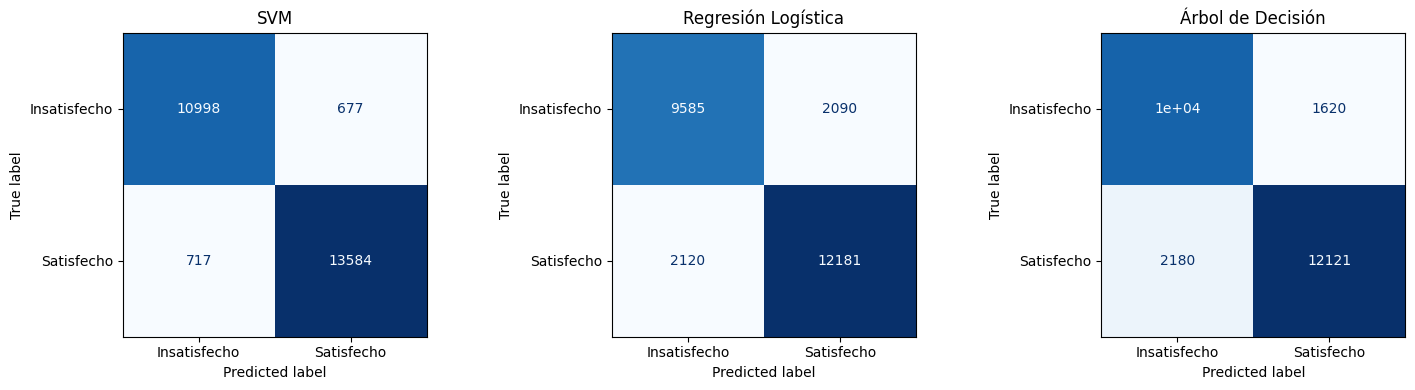

In [ ]:
cm_svm = confusion_matrix(y_test, preds_svm_test)
cm_lr = confusion_matrix(y_test, preds_lr_test)
cm_tree = confusion_matrix(y_test, preds_tree_test)

# Visualización con los tres modelos lado a lado
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

modelos = [
    ('SVM', preds_svm_test),
    ('Regresión Logística', preds_lr_test),
    ('Árbol de Decisión', preds_tree_test)
]

for ax, (nombre, y_pred) in zip(axes, modelos):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['Insatisfecho', 'Satisfecho']
    )
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(nombre)
    ax.grid(False)

plt.tight_layout()
plt.show()

#### 17. Conclusiones de los resultados obtenidos

A continuación, se presentan las conclusiones basadas en los resultados de las métricas de los tres modelos (SVM, Regresión Logística y Árbol de Decisión):

##### 17.1 Análisis Comparativo de Modelos

1.  **Support Vector Machine (SVM):**
    *   **Rendimiento Superior:** El modelo SVM es el que presenta el mejor rendimiento en todas las métricas evaluadas: Accuracy (94.63%), Recall (94.99%), Precision (95.25%), F1-Score (95.12%), y ROC-AUC (98.81%).
    *   **Confiabilidad:** Su alto ROC-AUC indica una excelente capacidad para distinguir entre clientes satisfechos e insatisfechos. Un F1-Score también muy alto sugiere un buen equilibrio entre precisión y recall, lo que significa que el modelo es eficaz tanto en identificar a los clientes satisfechos como en evitar falsos positivos.
    *   **Matriz de Confusión:** La matriz de confusión del SVM probablemente mostraría una concentración de predicciones correctas en la diagonal principal, con muy pocos errores de clasificación en comparación con los otros modelos.

2.  **Regresión Logística:**
    *   **Rendimiento Moderado:** Este modelo mostró un rendimiento aceptable, pero significativamente inferior al SVM. Sus métricas de Accuracy (83.79%), Recall (85.18%), Precision (85.35%), F1-Score (85.27%) y ROC-AUC (90.94%) son consistentemente más bajas.
    *   **Utilidad:** A pesar de no ser el mejor, la Regresión Logística sigue siendo un modelo útil para entender la dirección y la magnitud de la relación entre las características y la satisfacción, aunque su poder predictivo es menor.

3.  **Árbol de Decisión:**
    *   **Rendimiento Moderado a Bueno:** El Árbol de Decisión se sitúa en un punto intermedio, con un rendimiento ligeramente mejor que la Regresión Logística en Accuracy (85.37%) y F1-Score (86.45%), pero con un Recall (84.76%) ligeramente inferior y un Precision (88.21%) superior. El ROC-AUC (90.57%) es similar al de la Regresión Logística.
    *   **Interpretabilidad:** Aunque no es el de mayor rendimiento, los árboles de decisión son modelos muy interpretables, lo cual puede ser valioso para entender qué características específicas llevan a ciertas decisiones de satisfacción.

#### 18. Conclusión General

El **modelo SVM** es claramente el **mejor modelo** entre los tres evaluados para predecir la satisfacción del cliente en este dataset. Su alto rendimiento en todas las métricas indica que es el más robusto y preciso para esta tarea de clasificación.

-------------------------------------

## Principales Hallazgos

- Los pasajeros de Clase Business presentan niveles de satisfacción significativamente superiores a los de las clases Eco y Eco Plus.
- El soporte online mostró una fuerte relación con la satisfacción general del cliente.
- Los retrasos de salida y llegada presentan una alta correlación y afectan negativamente la experiencia del pasajero.
- El servicio de WiFi obtuvo valoraciones relativamente bajas, representando una oportunidad de mejora.

## Resultados

Se entrenaron tres modelos de clasificación:

| Modelo | Accuracy | ROC-AUC |
|----------|----------|----------|
| SVM | 94.63% | 98.81% |
| Regresión Logística | 83.79% | 90.94% |
| Árbol de Decisión | 85.37% | 90.57% |

El modelo SVM obtuvo el mejor desempeño general, logrando una excelente capacidad de discriminación entre clientes satisfechos e insatisfechos.

## Limitaciones y Trabajo Futuro

- No se realizó optimización de hiperparámetros.
- No se implementaron pipelines de preprocesamiento.
- No se evaluaron modelos adicionales como Random Forest o XGBoost.
- Futuras versiones podrían incluir selección de variables y validación cruzada para mejorar la robustez del modelo.